In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gold_data = pd.read_csv("/content/drive/MyDrive/research/gold_data/expanded_triplet_evaluations_annotation_01 - SET03.csv")
gold_data['evdence_path_final'] = gold_data['Your_Annotation_supporting_evidence'].fillna(gold_data['supporting_evidence'])
gold_data_processed = gold_data.iloc[1:].copy()
gold_data_processed.head()

,doc_id,document,gold_summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_full,is_supported,Your annotation_is_supported,supporting_evidence,Your_Annotation_supporting_evidence,confidence,Your_Annotation_confidence,reasoning,Notes,evdence_path_final
1,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","['Exeter City', 'announced', 'record profits']",True,True,"[['Exeter City', 'declared', 'total profit of ...",NaN,2.0,2 - direct evidence,The summary triple states Exeter City announce...,NaN,"[['Exeter City', 'declared', 'total profit of ..."
2,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","['record profits', 'for', 'last financial year'],",True,True,"[[""Exeter City"", ""declared"", ""total profit of ...",NaN,2.0,2 - direct evidence,The summary triple connects 'record profits' t...,NaN,"[[""Exeter City"", ""declared"", ""total profit of ..."
3,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","[""Exeter City"", ""associated with"", ""last finan...",True,True,"[[""Exeter City"", ""declared"", ""total profit of ...",NaN,2.0,2 - direct evidence,The summary triple establishes an association ...,NaN,"[[""Exeter City"", ""declared"", ""total profit of ..."
4,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'is', 'Paralympic athlete']",True,True,"[['Hayayei', 'made Paralympic debut at', 'Rio ...",NaN,2.0,2 - direct evidence,The knowledge graph clearly establishes Hayaye...,NaN,"[['Hayayei', 'made Paralympic debut at', 'Rio ..."
5,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'died after', 'being hit ...",True,True,"[['man', 'struck by', 'metal pole'], ['Hayayei...",NaN,2.0,2 - direct evidence,The knowledge graph supports this through a cl...,NaN,"[['man', 'struck by', 'metal pole'], ['Hayayei..."


In [ ]:
data_df = pd.read_csv('/content/drive/MyDrive/research/data/inferencing/qwen3/08-03-26/results_traversal_qwen3_8b_t_01_no_algo.csv')
data_df.tail(10)

,doc_id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_subject,summary_triplet_predicate,summary_triplet_object,summary_triplet_full,is_supported,confidence,reasoning,supporting_evidence,fact_eval_res_lora
613,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",Hope Solo,suspended for,two internationals,"['Hope Solo', 'suspended for', 'two internatio...",False,0,The text shows Hope Solo 'will miss' matches a...,"[['Hope Solo', 'will miss', 'matches on 8 Febr...","{\n ""summary_triple"": [""Hope Solo"", ""suspende..."
614,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",Hope Solo,arrested for,driving under the influence,"['Hope Solo', 'arrested for', 'driving under t...",False,0,The text clearly states that Jerramy Stevens (...,"[['Jerramy Stevens', 'was arrested for', 'driv...","{\n ""summary_triple"": [""Hope Solo"", ""arrested..."
615,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",United States,has goalkeeper,Hope Solo,"['United States', 'has goalkeeper', 'Hope Solo']",False,0,While there's evidence of Hope Solo's connecti...,"[['negative impact', 'affected', 'US Soccer'],...","{\n ""summary_triple"": [""United States"", ""has ..."
616,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",driving under the influence,resulted in,suspension,"['driving under the influence', 'resulted in',...",False,0,The text shows driving under the influence occ...,"[['Jerramy Stevens', 'was arrested for', 'driv...","{\n ""summary_triple"": [""driving under the inf..."
617,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",two internationals,related to,suspension,"['two internationals', 'related to', 'suspensi...",False,0,The text shows Hope Solo will miss two interna...,"[['Hope Solo', 'will miss', 'matches on 8 Febr...","{\n ""summary_triple"": [""two internationals"", ..."
618,35844158,"Omar Khan, 31, had worked at The Johnson Partn...",A barrister who was due to move into his own c...,A solicitor has admitted conspiring to supply ...,"[['Omar Khan', 'worked at', 'The Johnson Partn...","[['solicitor', 'admitted', 'conspiring to supp...",solicitor,admitted,conspiring to supply cocaine,"['solicitor', 'admitted', 'conspiring to suppl...",True,2,Omar Khan is identified as a solicitor through...,"[['Omar Khan', 'admitted', 'conspiracy to supp...","{\n ""summary_triple"": [""solicitor"", ""admitted..."
619,35844158,"Omar Khan, 31, had worked at The Johnson Partn...",A barrister who was due to move into his own c...,A solicitor has admitted conspiring to supply ...,"[['Omar Khan', 'worked at', 'The Johnson Partn...","[['solicitor', 'admitted', 'conspiring to supp...",solicitor,conspired with,three other men,"['solicitor', 'conspired with', 'three other m...",True,2,"The three men (Erlin Manahasa, Albert Dibra, N...","[['Erlin Manahasa', 'joined', 'Omar Khan'], ['...","{\n ""summary_triple"": [""solicitor"", ""conspire..."
620,35844158,"Omar Khan, 31

In [ ]:
import json
import ast

# Re-load the original data
data_df = pd.read_csv('/content/drive/MyDrive/research/data/inferencing/qwen3/08-03-26/results_traversal_qwen3_8b_t_01_no_algo.csv')

def parse_fact_eval(s):
    """Parse fact_eval_res with multiple fallback strategies"""
    # Strategy 1: Fix double braces and extra brackets, try JSON
    s_fixed = s.replace('{{', '{').replace('}}', '}')
    if s_fixed.endswith('}]}]'):
        s_fixed = s_fixed[:-2]

    try:
        return json.loads(s_fixed)
    except:
        pass

    # Strategy 2: Try using ast.literal_eval (handles single quotes)
    try:
        # First fix the double braces and extra brackets
        s_fixed = s.replace('{{', '{').replace('}}', '}')
        if s_fixed.endswith('}]}]'):
            s_fixed = s_fixed[:-2]

        # Replace true/false/null with Python equivalents for ast.literal_eval
        s_fixed = s_fixed.replace('true', 'True').replace('false', 'False').replace('null', 'None')
        return ast.literal_eval(s_fixed)
    except:
        pass

    return None

# Expand the fact_eval_res column - create one row per evaluation item
rows = []
parse_errors = []

for idx, row in data_df.iterrows():
    try:
        # Parse the JSON string
        parsed = parse_fact_eval(str(row['fact_eval_res_lora']))

        # Handle both dict and list cases
        if parsed:
            # If it's a single dict, wrap it in a list
            if isinstance(parsed, dict):
                parsed = [parsed]

            # If it's a list with items, create a row for each item
            if isinstance(parsed, list) and len(parsed) > 0:
                for eval_result in parsed:
                    new_row = row.to_dict()
                    new_row['summary_triple'] = str(eval_result.get('summary_triple', None))
                    new_row['is_supported'] = eval_result.get('is_supported', None)
                    new_row['supporting_evidence'] = str(eval_result.get('supporting_evidence', None))
                    new_row['confidence'] = eval_result.get('confidence', None)
                    new_row['reasoning'] = eval_result.get('reasoning', None)
                    rows.append(new_row)
            else:
                # Empty list case
                parse_errors.append({
                    'idx': idx,
                    'fact_eval_res': str(row['fact_eval_res_lora'])
                })
                new_row = row.to_dict()
                new_row['summary_triple'] = None
                new_row['is_supported'] = None
                new_row['supporting_evidence'] = None
                new_row['confidence'] = None
                new_row['reasoning'] = None
                rows.append(new_row)
        else:
            # If parsing fails or list is empty, keep original row with None values
            parse_errors.append({
                'idx': idx,
                'fact_eval_res': str(row['fact_eval_res_lora'])
            })
            new_row = row.to_dict()
            new_row['summary_triple'] = None
            new_row['is_supported'] = None
            new_row['supporting_evidence'] = None
            new_row['confidence'] = None
            new_row['reasoning'] = None
            rows.append(new_row)
    except Exception as e:
        # If parsing fails, keep original row with None values and log the error
        parse_errors.append({
            'idx': idx,
            'error': str(e),
            'fact_eval_res': str(row['fact_eval_res_lora'])
        })
        new_row = row.to_dict()
        new_row['summary_triple'] = None
        new_row['is_supported'] = None
        new_row['supporting_evidence'] = None
        new_row['confidence'] = None
        new_row['reasoning'] = None
        rows.append(new_row)

# Create new dataframe with expanded rows
data_df = pd.DataFrame(rows)

print(f"Total rows: {len(data_df)}")
print(f"Parse errors: {len(parse_errors)}")
print(f"Rows with is_supported=True: {(data_df['is_supported'] == True).sum()}")
print(f"Rows with is_supported=False: {(data_df['is_supported'] == False).sum()}")
print(f"Rows with is_supported=None: {data_df['is_supported'].isna().sum()}")
print(f"\nValue counts:")
print(data_df['is_supported'].value_counts(dropna=False))

if parse_errors:
    print(f"\nFirst few remaining errors:")
    for i, error in enumerate(parse_errors):
        print(f"\nError {i+1} at row {error['idx']}:")
        print(f"  Data: {error['fact_eval_res']}")
        if 'error' in error:
            print(f"  Error: {error['error']}")

# Display the result
data_df.tail(10)

Total rows: 623
Parse errors: 0
Rows with is_supported=True: 374
Rows with is_supported=False: 249
Rows with is_supported=None: 0

Value counts:
is_supported
True     374
False    249
Name: count, dtype: int64


,doc_id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_subject,summary_triplet_predicate,summary_triplet_object,summary_triplet_full,is_supported,confidence,reasoning,supporting_evidence,fact_eval_res_lora,summary_triple
613,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",Hope Solo,suspended for,two internationals,"['Hope Solo', 'suspended for', 'two internatio...",True,2,The summary triplet indicates Hope Solo was su...,"[['Hope Solo', 'will miss', 'matches on 8 Febr...","{\n ""summary_triple"": [""Hope Solo"", ""suspende...","['Hope Solo', 'suspended for', 'two internatio..."
614,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",Hope Solo,arrested for,driving under the influence,"['Hope Solo', 'arrested for', 'driving under t...",False,0,The summary triplet suggests Hope Solo was arr...,"[['Jerramy Stevens', 'was arrested for', 'driv...","{\n ""summary_triple"": [""Hope Solo"", ""arrested...","['Hope Solo', 'arrested for', 'driving under t..."
615,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",United States,has goalkeeper,Hope Solo,"['United States', 'has goalkeeper', 'Hope Solo']",True,2,The United States' association with Hope Solo ...,"[['US', 'preparing for', ""Women's World Cup""],...","{\n ""summary_triple"": [""United States"", ""has ...","['United States', 'has goalkeeper', 'Hope Solo']"
616,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",driving under the influence,resulted in,suspension,"['driving under the influence', 'resulted in',...",False,0,The summary triplet suggests a direct relation...,"[['Jerramy Stevens', 'was arrested for', 'driv...","{\n ""summary_triple"": [""driving under the inf...","['driving under the influence', 'resulted in',..."
617,30931494,"""Hope made a poor decision that has resulted i...",The United States women's team goalkeeper Hope...,United States goalkeeper Hope Solo has been su...,"[['Hope Solo', 'made', 'poor decision'], ['poo...","[['Hope Solo', 'is', 'United States goalkeeper...",two internationals,related to,suspension,"['two internationals', 'related to', 'suspensi...",True,2,'Two internationals' refers to international m...,"[['Hope Solo', 'will miss', 'matches on 8 Febr...","{\n ""summary_triple"": [""two internationals"", ...","['two internationals', 'related to', 'suspensi..."
618,35844158,"Omar Khan, 31, had worked at The Johnson Partn...",A barrister who was due to move into his own c...,A solicitor has admitted conspiring to supply ...,"[['Omar Khan', 'worked at', 'The Johnson Partn...","[['solicitor', 'admitted', 'conspiring to supp...",solicitor,admitted,conspiring to supply cocaine,"['solicitor', 'admitted', 'conspiring to suppl...",False,0,The summary triplet implies a relationship bet...,"[['Omar Khan', 'admitted', 'conspiracy to supp...","{\n ""summary_triple"": [""solicitor"", ""admitted...","['solicitor', 'admitted', 'conspiring to suppl..."
619,35844158,"Omar Khan, 31, had worked at The Johnson Partn...",A barrister who was due to move into his own c...,A solicitor has admitted conspiring to supply ...,"[['Omar Khan', 'worked at', 'The Johnson Partn...","[['solicitor

In [ ]:
# save the expanded
data_df.to_csv("/content/drive/MyDrive/research/data/inferencing/qwen3/08-03-26/results_traversal_qwen3_8b_t_01_no_algo_expanded.csv")

#cqwen3 lora 4bit quantized

In [ ]:
data_df1 = pd.read_csv("/content/drive/MyDrive/research/data/inferencing/qwen3/08-03-26/results_traversal_qwen3_8b_t_01_no_algo_expanded.csv")
data_df1.head()

,doc_id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_full,fact_eval_res_lora,summary_triple,is_supported,supporting_evidence,confidence,reasoning
0,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['More than 1,000 homeless people', 'referred ...","{\n ""summary_triple"": [""More than 1,000 homel...","['More than 1,000 homeless people', 'referred ...",True,"[['Prison Link Cymru', 'had', '1,099 referrals...",2,"The summary triplet states that 'More than 1,0..."
1,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['charity', 'located in', 'Wales']","{\n ""summary_triple"": [""charity"", ""located in...","['charity', 'located in', 'Wales']",True,"[['Housing Act', 'in', 'Wales'], ['Emmaus', 'i...",2,The summary triplet 'charity located in Wales'...
2,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['referral', 'occurred in', 'last year']","{\n ""summary_triple"": [""referral"", ""occurred ...","['referral', 'occurred in', 'last year']",False,"[['Prison Link Cymru', 'had', '1,099 referrals']]",1,The summary triplet suggests that referrals oc...
3,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['More than 1,000 homeless people', 'associate...","{\n ""summary_triple"": [""More than 1,000 homel...","['More than 1,000 homeless people', 'associate...",True,"[['Prison Link Cymru', 'had', '1,099 referrals...",2,"The summary triplet states that 'More than 1,0..."
4,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['charity', 'associated with', 'last year']","{\n ""summary_triple"": [""charity"", ""associated...","['charity', 'associated with', 'last year']",False,"[['Prison Link Cymru', 'operates in', '2015-16']]",1,The summary triplet suggests an association be...


In [ ]:
data_df1_processed = data_df1.iloc[413:].copy()


In [ ]:
merged_df = pd.merge(gold_data_processed, data_df1_processed,
                     on=['doc_id', 'summary_triplet_full'],
                     suffixes=('_gold', '_data_df1'),
                     how='inner')

print("Merged DataFrame head:")
print(merged_df.head())
print(f"\nNumber of rows in merged_df: {len(merged_df)}")

# print the column names
print("\nColumn names in merged_df:")
print(merged_df.columns)

Merged DataFrame head:
       doc_id                                      document_gold  \
0  35714830.0  The club, which is owned by its fans via the E...   
1  40577419.0  The United Arab Emirates thrower was training ...   
2  40577419.0  The United Arab Emirates thrower was training ...   
3  40577419.0  The United Arab Emirates thrower was training ...   
4  40577419.0  The United Arab Emirates thrower was training ...   

                                        gold_summary  \
0  League Two Exeter City made a profit of over £...   
1  Para-athlete Abdullah Hayayei died after a met...   
2  Para-athlete Abdullah Hayayei died after a met...   
3  Para-athlete Abdullah Hayayei died after a met...   
4  Para-athlete Abdullah Hayayei died after a met...   

                              generated_summary_gold  \
0  Exeter City have announced record profits for ...   
1  Paralympic athlete Abdullah Hayayei has died a...   
2  Paralympic athlete Abdullah Hayayei has died a...   
3  Para

In [ ]:
import ast
import pandas as pd

def safe_literal_eval_is_supported(x):
    if pd.isna(x):
        return None
    try:
        # Preprocess the string to convert JSON boolean literals to Python boolean literals
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'is_supported' in evaluated_dict:
            return evaluated_dict['is_supported']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'is_supported'
merged_df['fact_eval_res_lora_is_supported'] = merged_df['fact_eval_res_lora'].apply(safe_literal_eval_is_supported)

# Ensure both columns are boolean type for accurate comparison
# Handle potential None values before converting to bool, as astype(bool) converts None to False
merged_df['Your annotation_is_supported'] = merged_df['Your annotation_is_supported'].astype(bool)
merged_df['fact_eval_res_lora_is_supported'] = merged_df['fact_eval_res_lora_is_supported'].astype(bool)

comparison_series = (merged_df['Your annotation_is_supported'] == merged_df['fact_eval_res_lora_is_supported'])

total_entries = len(comparison_series)
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total entries compared: {total_entries}")
print(f"Matching 'is_supported' values: {matching_entries}")
print(f"Non-matching 'is_supported' values: {non_matching_entries}")
print(f"Percentage of agreement: {agreement_percentage:.2f}%")

Total entries compared: 208
Matching 'is_supported' values: 176
Non-matching 'is_supported' values: 32
Percentage of agreement: 84.62%


In [ ]:
confusion_matrix = pd.crosstab(merged_df['Your annotation_is_supported'], merged_df['fact_eval_res_lora_is_supported'],
                                 rownames=['Gold Data (Your Annotation_is_supported)'],
                                 colnames=['data_df1 (is_supported)'],
                                 margins=True)

print("Confusion Matrix for 'is_supported' columns:")
display(confusion_matrix)

Confusion Matrix for 'is_supported' columns:


data_df1 (is_supported),False,True,All
Gold Data (Your Annotation_is_supported),,,
False,60,7,67
True,25,116,141
All,85,123,208


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix.loc[False, False]
FP = confusion_matrix.loc[False, True]
FN = confusion_matrix.loc[True, False]
TP = confusion_matrix.loc[True, True]

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.8462
Precision: 0.9431
Recall: 0.8227
F1-score: 0.8788
Specificity: 0.8955
Balanced Accuracy: 0.8591


In [ ]:
import ast
import pandas as pd
import re # Import regex module

def safe_literal_eval_confidence(x):
    if pd.isna(x):
        return None
    try:
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'confidence' in evaluated_dict:
            return evaluated_dict['confidence']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'confidence'
merged_df['fact_eval_res_lora_confidence'] = merged_df['fact_eval_res_lora'].apply(safe_literal_eval_confidence)

# Safely extract the first numeric character from 'Your_Annotation_confidence' and convert to int
def extract_first_digit(text):
    if pd.isna(text):
        return None
    s = str(text).strip()
    match = re.match(r'(\d)', s) # Find the first digit at the beginning of the string
    if match:
        return int(match.group(1))
    return None

merged_df['Your_Annotation_confidence_numeric'] = merged_df['Your_Annotation_confidence'].apply(extract_first_digit)

# Filter out rows where either confidence value is None for comparison
comparable_df = merged_df.dropna(subset=['Your_Annotation_confidence_numeric', 'fact_eval_res_lora_confidence']).copy()

# Ensure both columns are integer type for accurate comparison in the comparable_df
comparable_df['Your_Annotation_confidence_numeric'] = comparable_df['Your_Annotation_confidence_numeric'].astype(int)
comparable_df['fact_eval_res_lora_confidence'] = comparable_df['fact_eval_res_lora_confidence'].astype(int)

comparison_series = (comparable_df['Your_Annotation_confidence_numeric'] == comparable_df['fact_eval_res_lora_confidence'])

total_entries = len(comparison_series) # Now, total_entries reflects only comparable entries
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total comparable entries (confidence): {total_entries}")
print(f"Matching 'confidence' values: {matching_entries}")
print(f"Non-matching 'confidence' values: {non_matching_entries}")
print(f"Percentage of agreement (confidence): {agreement_percentage:.2f}%")


Total comparable entries (confidence): 206
Matching 'confidence' values: 142
Non-matching 'confidence' values: 64
Percentage of agreement (confidence): 68.93%


In [ ]:
merged_df['gold_confidence_char'] = merged_df['Your_Annotation_confidence_numeric'].astype(str)
merged_df['data_df1_confidence_char'] = merged_df['fact_eval_res_lora_confidence'].astype(str)

valid_confidence_values = ['1', '2']

# Create a filtered_df directly from the comparable_df which already has valid integer confidence values
# This ensures that when converted to string, they will be '1' or '2'
filtered_comparable_df = comparable_df[
    (comparable_df['Your_Annotation_confidence_numeric'].astype(str).isin(valid_confidence_values)) &
    (comparable_df['fact_eval_res_lora_confidence'].astype(str).isin(valid_confidence_values))
]

confusion_matrix_confidence = pd.crosstab(
    filtered_comparable_df['Your_Annotation_confidence_numeric'].astype(str),
    filtered_comparable_df['fact_eval_res_lora_confidence'].astype(str),
    rownames=['Gold Data (Confidence First Char)'],
    colnames=['data_df1 (Confidence First Char)'],
    margins=True
)

print("Confusion Matrix for Confidence (values '1' or '2'):")
display(confusion_matrix_confidence)


Confusion Matrix for Confidence (values '1' or '2'):


data_df1 (Confidence First Char),1,2,All
Gold Data (Confidence First Char),,,
1,8,14,22
2,17,84,101
All,25,98,123


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix_confidence.loc['1', '1']
FP = confusion_matrix_confidence.loc['1', '2']
FN = confusion_matrix_confidence.loc['2', '1']
TP = confusion_matrix_confidence.loc['2', '2']

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.7480
Precision: 0.8571
Recall: 0.8317
F1-score: 0.8442
Specificity: 0.3636
Balanced Accuracy: 0.5977


# qwen3 8b lora check 300 temp 0.1 without algo

In [ ]:
data_df1 = pd.read_csv("/content/drive/MyDrive/research/data/inferencing/lora_inference/qwen3/27-02-26/results_traversal_ck_300_t_01_no_algo.csv")
data_df1.head()

,doc_id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_subject,summary_triplet_predicate,summary_triplet_object,summary_triplet_full,is_supported,confidence,reasoning,supporting_evidence,fact_eval_res_lora
0,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","More than 1,000 homeless people",referred to,charity,"['More than 1,000 homeless people', 'referred ...",True,2,"Prison Link Cymru (charity) had 1,099 referral...","[['Prison Link Cymru', 'had', '1,099 referrals']]","{""summary_triple"": [""More than 1,000 homeless ..."
1,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...",charity,located in,Wales,"['charity', 'located in', 'Wales']",True,2,"Prison Link Cymru is the charity mentioned, an...","[['Prison Link Cymru', 'operates in', '2015-16...","{""summary_triple"": [""charity"", ""located in"", ""..."
2,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...",referral,occurred in,last year,"['referral', 'occurred in', 'last year']",True,2,"Prison Link Cymru had 1,099 referrals and oper...","[['Prison Link Cymru', 'operates in', '2015-16...","{""summary_triple"": [""referral"", ""occurred in"",..."
3,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","More than 1,000 homeless people",associated with,Wales,"['More than 1,000 homeless people', 'associate...",True,2,"The 1,099 referrals to Prison Link Cymru (more...","[['Prison Link Cymru', 'had', '1,099 referrals...","{""summary_triple"": [""More than 1,000 homeless ..."
4,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...",charity,associated with,last year,"['charity', 'associated with', 'last year']",True,2,Prison Link Cymru (the charity) operates in 20...,"[['Prison Link Cymru', 'operates in', '2015-16...","{""summary_triple"": [""charity"", ""associated wit..."


In [ ]:
data_df1_processed = data_df1.iloc[413:].copy()

merged_df = pd.merge(gold_data_processed, data_df1_processed,
                     on=['doc_id', 'summary_triplet_full'],
                     suffixes=('_gold', '_data_df1'),
                     how='inner')

print("Merged DataFrame head:")
print(merged_df.head())
print(f"\nNumber of rows in merged_df: {len(merged_df)}")

# print the column names
print("\nColumn names in merged_df:")
print(merged_df.columns)

Merged DataFrame head:
       doc_id                                      document_gold  \
0  35714830.0  The club, which is owned by its fans via the E...   
1  40577419.0  The United Arab Emirates thrower was training ...   
2  40577419.0  The United Arab Emirates thrower was training ...   
3  40577419.0  The United Arab Emirates thrower was training ...   
4  40577419.0  The United Arab Emirates thrower was training ...   

                                        gold_summary  \
0  League Two Exeter City made a profit of over £...   
1  Para-athlete Abdullah Hayayei died after a met...   
2  Para-athlete Abdullah Hayayei died after a met...   
3  Para-athlete Abdullah Hayayei died after a met...   
4  Para-athlete Abdullah Hayayei died after a met...   

                              generated_summary_gold  \
0  Exeter City have announced record profits for ...   
1  Paralympic athlete Abdullah Hayayei has died a...   
2  Paralympic athlete Abdullah Hayayei has died a...   
3  Para

In [ ]:
import ast
import pandas as pd

def safe_literal_eval_is_supported(x):
    if pd.isna(x):
        return None
    try:
        # Preprocess the string to convert JSON boolean literals to Python boolean literals
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'is_supported' in evaluated_dict:
            return evaluated_dict['is_supported']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'is_supported'
merged_df['fact_eval_res_lora_is_supported'] = merged_df['fact_eval_res_lora'].apply(safe_literal_eval_is_supported)

# Ensure both columns are boolean type for accurate comparison
# Handle potential None values before converting to bool, as astype(bool) converts None to False
merged_df['Your annotation_is_supported'] = merged_df['Your annotation_is_supported'].astype(bool)
merged_df['fact_eval_res_lora_is_supported'] = merged_df['fact_eval_res_lora_is_supported'].astype(bool)

comparison_series = (merged_df['Your annotation_is_supported'] == merged_df['fact_eval_res_lora_is_supported'])

total_entries = len(comparison_series)
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total entries compared: {total_entries}")
print(f"Matching 'is_supported' values: {matching_entries}")
print(f"Non-matching 'is_supported' values: {non_matching_entries}")
print(f"Percentage of agreement: {agreement_percentage:.2f}%")

Total entries compared: 208
Matching 'is_supported' values: 175
Non-matching 'is_supported' values: 33
Percentage of agreement: 84.13%


In [ ]:
confusion_matrix = pd.crosstab(merged_df['Your annotation_is_supported'], merged_df['fact_eval_res_lora_is_supported'],
                                 rownames=['Gold Data (Your Annotation_is_supported)'],
                                 colnames=['data_df1 (is_supported)'],
                                 margins=True)

print("Confusion Matrix for 'is_supported' columns:")
display(confusion_matrix)

Confusion Matrix for 'is_supported' columns:


data_df1 (is_supported),False,True,All
Gold Data (Your Annotation_is_supported),,,
False,53,14,67
True,19,122,141
All,72,136,208


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix.loc[False, False]
FP = confusion_matrix.loc[False, True]
FN = confusion_matrix.loc[True, False]
TP = confusion_matrix.loc[True, True]

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.8413
Precision: 0.8971
Recall: 0.8652
F1-score: 0.8809
Specificity: 0.7910
Balanced Accuracy: 0.8281


In [ ]:
import ast
import pandas as pd
import re # Import regex module

def safe_literal_eval_confidence(x):
    if pd.isna(x):
        return None
    try:
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'confidence' in evaluated_dict:
            return evaluated_dict['confidence']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'confidence'
merged_df['fact_eval_res_lora_confidence'] = merged_df['fact_eval_res_lora'].apply(safe_literal_eval_confidence)

# Safely extract the first numeric character from 'Your_Annotation_confidence' and convert to int
def extract_first_digit(text):
    if pd.isna(text):
        return None
    s = str(text).strip()
    match = re.match(r'(\d)', s) # Find the first digit at the beginning of the string
    if match:
        return int(match.group(1))
    return None

merged_df['Your_Annotation_confidence_numeric'] = merged_df['Your_Annotation_confidence'].apply(extract_first_digit)

# Filter out rows where either confidence value is None for comparison
comparable_df = merged_df.dropna(subset=['Your_Annotation_confidence_numeric', 'fact_eval_res_lora_confidence']).copy()

# Ensure both columns are integer type for accurate comparison in the comparable_df
comparable_df['Your_Annotation_confidence_numeric'] = comparable_df['Your_Annotation_confidence_numeric'].astype(int)
comparable_df['fact_eval_res_lora_confidence'] = comparable_df['fact_eval_res_lora_confidence'].astype(int)

comparison_series = (comparable_df['Your_Annotation_confidence_numeric'] == comparable_df['fact_eval_res_lora_confidence'])

total_entries = len(comparison_series) # Now, total_entries reflects only comparable entries
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total comparable entries (confidence): {total_entries}")
print(f"Matching 'confidence' values: {matching_entries}")
print(f"Non-matching 'confidence' values: {non_matching_entries}")
print(f"Percentage of agreement (confidence): {agreement_percentage:.2f}%")


Total comparable entries (confidence): 206
Matching 'confidence' values: 133
Non-matching 'confidence' values: 73
Percentage of agreement (confidence): 64.56%


In [ ]:
merged_df['gold_confidence_char'] = merged_df['Your_Annotation_confidence_numeric'].astype(str)
merged_df['data_df1_confidence_char'] = merged_df['fact_eval_res_lora_confidence'].astype(str)

valid_confidence_values = ['1', '2']

# Create a filtered_df directly from the comparable_df which already has valid integer confidence values
# This ensures that when converted to string, they will be '1' or '2'
filtered_comparable_df = comparable_df[
    (comparable_df['Your_Annotation_confidence_numeric'].astype(str).isin(valid_confidence_values)) &
    (comparable_df['fact_eval_res_lora_confidence'].astype(str).isin(valid_confidence_values))
]

confusion_matrix_confidence = pd.crosstab(
    filtered_comparable_df['Your_Annotation_confidence_numeric'].astype(str),
    filtered_comparable_df['fact_eval_res_lora_confidence'].astype(str),
    rownames=['Gold Data (Confidence First Char)'],
    colnames=['data_df1 (Confidence First Char)'],
    margins=True
)

print("Confusion Matrix for Confidence (values '1' or '2'):")
display(confusion_matrix_confidence)


Confusion Matrix for Confidence (values '1' or '2'):


data_df1 (Confidence First Char),1,2,All
Gold Data (Confidence First Char),,,
1,12,9,21
2,33,69,102
All,45,78,123


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix_confidence.loc['1', '1']
FP = confusion_matrix_confidence.loc['1', '2']
FN = confusion_matrix_confidence.loc['2', '1']
TP = confusion_matrix_confidence.loc['2', '2']

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.6585
Precision: 0.8846
Recall: 0.6765
F1-score: 0.7667
Specificity: 0.5714
Balanced Accuracy: 0.6239


## Qwen3 8b lora check 300 temp 0.1

need to redo with providing a hop limit -cuz the prompt was incomplete in earlier versions

In [ ]:
data_df1 = pd.read_csv("/content/drive/MyDrive/research/data/inferencing/lora_inference/qwen3/27-02-26/results_traversal_ck_300_t_01_v2_idk.csv")
data_df1.head()

,doc_id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_full,fact_eval_res_lora
0,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['More than 1,000 homeless people', 'referred ...","{""summary_triple"": [""More than 1,000 homeless ..."
1,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['charity', 'located in', 'Wales']","{""summary_triple"": [""charity"", ""located in"", ""..."
2,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['referral', 'occurred in', 'last year']","{""summary_triple"": [""referral"", ""occurred in"",..."
3,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['More than 1,000 homeless people', 'associate...","{""summary_triple"": [""More than 1,000 homeless ..."
4,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...","[['Prison Link Cymru', 'had', '1,099 referrals...","[['More than 1,000 homeless people', 'referred...","['charity', 'associated with', 'last year']","{""summary_triple"": [""charity"", ""associated wit..."


In [ ]:
row_number = data_df1[data_df1['doc_id'] == 35714830].index[0]
print(f"The row number of the first matching row is: {row_number}")

The row number of the first matching row is: 413


In [ ]:
gold_data_processed = gold_data.iloc[1:].copy()
# data_df1_processed = data_df1.iloc[413:].copy()

# print("gold_data_processed head:")
# display(gold_data_processed.head())
# print("\n")
# print("data_df1_processed head:")
# display(data_df1_processed.head())

**Reasoning**:
Now that both dataframes are preprocessed, I need to merge them to compare the relevant columns. The merging will be done on 'doc_id' and 'summary_triplet_full' as specified in the main task.



In [ ]:
merged_df = pd.merge(gold_data_processed, data_df1_processed,
                     on=['doc_id', 'summary_triplet_full'],
                     suffixes=('_gold', '_data_df1'),
                     how='inner')

print("Merged DataFrame head:")
print(merged_df.head())
print(f"\nNumber of rows in merged_df: {len(merged_df)}")

# print the column names
print("\nColumn names in merged_df:")
print(merged_df.columns)

Merged DataFrame head:
       doc_id                                      document_gold  \
0  35714830.0  The club, which is owned by its fans via the E...   
1  40577419.0  The United Arab Emirates thrower was training ...   
2  40577419.0  The United Arab Emirates thrower was training ...   
3  40577419.0  The United Arab Emirates thrower was training ...   
4  40577419.0  The United Arab Emirates thrower was training ...   

                                        gold_summary  \
0  League Two Exeter City made a profit of over £...   
1  Para-athlete Abdullah Hayayei died after a met...   
2  Para-athlete Abdullah Hayayei died after a met...   
3  Para-athlete Abdullah Hayayei died after a met...   
4  Para-athlete Abdullah Hayayei died after a met...   

                              generated_summary_gold  \
0  Exeter City have announced record profits for ...   
1  Paralympic athlete Abdullah Hayayei has died a...   
2  Paralympic athlete Abdullah Hayayei has died a...   
3  Para

In [ ]:
#no of null elements in the column 'evdence_path_final'
merged_df['evdence_path_final'].isna().sum()

np.int64(0)

**Reasoning**:
Now that the dataframes are merged, I will compare the two 'is_supported' columns, calculate matching and non-matching entries, and determine the percentage of agreement to summarize the comparison results.



In [ ]:
merged_df['fact_eval_res_lora'][0]

'{"summary_triple": ["Exeter City", "announced", "record profits"], "is_supported": true, "supporting_evidence": [["Exeter City", "declared", "total profit of £1.642m"]], "confidence": 2, "reasoning": "Direct single-hop path: Exeter City declared total profit of £1.642m"}'

In [ ]:
import ast
import pandas as pd

def safe_literal_eval_is_supported(x):
    if pd.isna(x):
        return None
    try:
        # Preprocess the string to convert JSON boolean literals to Python boolean literals
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'is_supported' in evaluated_dict:
            return evaluated_dict['is_supported']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'is_supported'
merged_df['fact_eval_res_lora_is_supported'] = merged_df['fact_eval_res_lora'].apply(safe_literal_eval_is_supported)

# Ensure both columns are boolean type for accurate comparison
# Handle potential None values before converting to bool, as astype(bool) converts None to False
merged_df['Your annotation_is_supported'] = merged_df['Your annotation_is_supported'].astype(bool)
merged_df['fact_eval_res_lora_is_supported'] = merged_df['fact_eval_res_lora_is_supported'].astype(bool)

comparison_series = (merged_df['Your annotation_is_supported'] == merged_df['fact_eval_res_lora_is_supported'])

total_entries = len(comparison_series)
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total entries compared: {total_entries}")
print(f"Matching 'is_supported' values: {matching_entries}")
print(f"Non-matching 'is_supported' values: {non_matching_entries}")
print(f"Percentage of agreement: {agreement_percentage:.2f}%")

Total entries compared: 208
Matching 'is_supported' values: 175
Non-matching 'is_supported' values: 33
Percentage of agreement: 84.13%


In [ ]:
confusion_matrix = pd.crosstab(merged_df['Your annotation_is_supported'], merged_df['fact_eval_res_lora_is_supported'],
                                 rownames=['Gold Data (Your Annotation_is_supported)'],
                                 colnames=['data_df1 (is_supported)'],
                                 margins=True)

print("Confusion Matrix for 'is_supported' columns:")
display(confusion_matrix)

Confusion Matrix for 'is_supported' columns:


data_df1 (is_supported),False,True,All
Gold Data (Your Annotation_is_supported),,,
False,53,14,67
True,19,122,141
All,72,136,208


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix.loc[False, False]
FP = confusion_matrix.loc[False, True]
FN = confusion_matrix.loc[True, False]
TP = confusion_matrix.loc[True, True]

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.8413
Precision: 0.8971
Recall: 0.8652
F1-score: 0.8809
Specificity: 0.7910
Balanced Accuracy: 0.8281


In [ ]:
import ast
import pandas as pd
import re # Import regex module

def safe_literal_eval_confidence(x):
    if pd.isna(x):
        return None
    try:
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'confidence' in evaluated_dict:
            return evaluated_dict['confidence']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'confidence'
merged_df['fact_eval_res_lora_confidence'] = merged_df['fact_eval_res_lora'].apply(safe_literal_eval_confidence)

# Safely extract the first numeric character from 'Your_Annotation_confidence' and convert to int
def extract_first_digit(text):
    if pd.isna(text):
        return None
    s = str(text).strip()
    match = re.match(r'(\d)', s) # Find the first digit at the beginning of the string
    if match:
        return int(match.group(1))
    return None

merged_df['Your_Annotation_confidence_numeric'] = merged_df['Your_Annotation_confidence'].apply(extract_first_digit)

# Filter out rows where either confidence value is None for comparison
comparable_df = merged_df.dropna(subset=['Your_Annotation_confidence_numeric', 'fact_eval_res_lora_confidence']).copy()

# Ensure both columns are integer type for accurate comparison in the comparable_df
comparable_df['Your_Annotation_confidence_numeric'] = comparable_df['Your_Annotation_confidence_numeric'].astype(int)
comparable_df['fact_eval_res_lora_confidence'] = comparable_df['fact_eval_res_lora_confidence'].astype(int)

comparison_series = (comparable_df['Your_Annotation_confidence_numeric'] == comparable_df['fact_eval_res_lora_confidence'])

total_entries = len(comparison_series) # Now, total_entries reflects only comparable entries
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total comparable entries (confidence): {total_entries}")
print(f"Matching 'confidence' values: {matching_entries}")
print(f"Non-matching 'confidence' values: {non_matching_entries}")
print(f"Percentage of agreement (confidence): {agreement_percentage:.2f}%")


Total comparable entries (confidence): 206
Matching 'confidence' values: 142
Non-matching 'confidence' values: 64
Percentage of agreement (confidence): 68.93%


In [ ]:
merged_df['gold_confidence_char'] = merged_df['Your_Annotation_confidence_numeric'].astype(str)
merged_df['data_df1_confidence_char'] = merged_df['fact_eval_res_lora_confidence'].astype(str)

valid_confidence_values = ['1', '2']

# Create a filtered_df directly from the comparable_df which already has valid integer confidence values
# This ensures that when converted to string, they will be '1' or '2'
filtered_comparable_df = comparable_df[
    (comparable_df['Your_Annotation_confidence_numeric'].astype(str).isin(valid_confidence_values)) &
    (comparable_df['fact_eval_res_lora_confidence'].astype(str).isin(valid_confidence_values))
]

confusion_matrix_confidence = pd.crosstab(
    filtered_comparable_df['Your_Annotation_confidence_numeric'].astype(str),
    filtered_comparable_df['fact_eval_res_lora_confidence'].astype(str),
    rownames=['Gold Data (Confidence First Char)'],
    colnames=['data_df1 (Confidence First Char)'],
    margins=True
)

print("Confusion Matrix for Confidence (values '1' or '2'):")
display(confusion_matrix_confidence)


Confusion Matrix for Confidence (values '1' or '2'):


data_df1 (Confidence First Char),1,2,All
Gold Data (Confidence First Char),,,
1,15,8,23
2,26,73,99
All,41,81,122


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix_confidence.loc['1', '1']
FP = confusion_matrix_confidence.loc['1', '2']
FN = confusion_matrix_confidence.loc['2', '1']
TP = confusion_matrix_confidence.loc['2', '2']

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")

Accuracy: 0.7213
Precision: 0.9012
Recall: 0.7374
F1-score: 0.8111


qwen 3 8b lora chk 500 temp 0.1

In [ ]:
data_df2 = pd.read_csv("/content/drive/MyDrive/research/data/inferencing/lora_inference/qwen3/21-02-26/results_traversal_lora_ck_500_t_01.csv")
row_number = data_df2[data_df2['doc_id'] == 35714830].index[0]
print(f"The row number of the first matching row is: {row_number}")

The row number of the first matching row is: 413


In [ ]:
data_df2_processed = data_df2.iloc[413:].copy()


In [ ]:
merged_df2 = pd.merge(gold_data_processed, data_df2_processed,
                     on=['doc_id', 'summary_triplet_full'],
                     suffixes=('_gold', '_data_df2'),
                     how='inner')

print("Merged DataFrame head:")
display(merged_df2.head())
print(f"\nNumber of rows in merged_df: {len(merged_df2)}")

Merged DataFrame head:


,doc_id,document_gold,gold_summary,generated_summary_gold,document_triplets_gold,gen_summary_triplets_gold,summary_triplet_full,is_supported_gold,Your annotation_is_supported,supporting_evidence_gold,...,document_triplets_data_df2,gen_summary_triplets_data_df2,summary_triplet_subject,summary_triplet_predicate,summary_triplet_object,is_supported_data_df2,confidence_data_df2,reasoning_data_df2,supporting_evidence_data_df2,fact_eval_res_lora
0,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","['Exeter City', 'announced', 'record profits']",True,True,"[['Exeter City', 'declared', 'total profit of ...",...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...",Exeter City,announced,record profits,False,0,While Exeter City declared a total profit of £...,"[['Exeter City', 'declared', 'total profit of ...","{""summary_triple"": [""Exeter City"", ""announced""..."
1,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'is', 'Paralympic athlete']",True,True,"[['Hayayei', 'made Paralympic debut at', 'Rio ...",...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...",Abdullah Hayayei,is,Paralympic athlete,True,2,Entity mapping: 'Abdullah Hayayei' maps to 'Ha...,"[['Hayayei', 'made Paralympic debut at', 'Rio ...","{""summary_triple"": [""Abdullah Hayayei"", ""is"", ..."
2,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'died after', 'being hit ...",True,True,"[['man', 'struck by', 'metal pole'], ['Hayayei...",...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...",Abdullah Hayayei,died after,being hit by a metal pole,True,2,Entity mapping: 'Abdullah Hayayei' maps to 'Ha...,"[['Hayayei', 'pronounced dead at', 'the scene'...","{""summary_triple"": [""Abdullah Hayayei"", ""died ..."
3,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'was hit during', 'traini...",True,True,"[['United Arab Emirates thrower', 'was trainin...",...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...",Abdullah Hayayei,was hit during,training session,True,2,Entity mapping: 'Abdullah Hayayei' maps to 'Un...,"[['United Arab Emirates thrower', 'was trainin...","{""summary_triple"": [""Abdullah Hayayei"", ""was h..."
4,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['metal pole', 'hit', 'Abdullah Hayayei']",True,True,"[['man', 'struck by', 'metal pole'], ['throwin...",...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...",metal pole,hit,Abdullah Hayayei,True,2,Entity mapping: 'Abdullah Hayayei' maps to 'ma...,"[['man', 'struck by', 'metal pole'], ['metal p...","{""summary_triple"": [""metal pole"", ""hit"", ""Abdu..."



Number of rows in merged_df: 208


In [ ]:
import ast
import pandas as pd

def safe_literal_eval_is_supported(x):
    if pd.isna(x):
        return None
    try:
        # Preprocess the string to convert JSON boolean literals to Python boolean literals
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'is_supported' in evaluated_dict:
            return evaluated_dict['is_supported']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'is_supported'
merged_df2['fact_eval_res_lora_is_supported'] = merged_df2['fact_eval_res_lora'].apply(safe_literal_eval_is_supported)

# Ensure both columns are boolean type for accurate comparison
# Handle potential None values before converting to bool, as astype(bool) converts None to False
merged_df2['Your annotation_is_supported'] = merged_df2['Your annotation_is_supported'].astype(bool)
merged_df2['fact_eval_res_lora_is_supported'] = merged_df2['fact_eval_res_lora_is_supported'].astype(bool)

comparison_series = (merged_df2['Your annotation_is_supported'] == merged_df2['fact_eval_res_lora_is_supported'])

total_entries = len(comparison_series)
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total entries compared: {total_entries}")
print(f"Matching 'is_supported' values: {matching_entries}")
print(f"Non-matching 'is_supported' values: {non_matching_entries}")
print(f"Percentage of agreement: {agreement_percentage:.2f}%")

Total entries compared: 208
Matching 'is_supported' values: 173
Non-matching 'is_supported' values: 35
Percentage of agreement: 83.17%


In [ ]:
confusion_matrix = pd.crosstab(merged_df2['Your annotation_is_supported'], merged_df2['fact_eval_res_lora_is_supported'],
                                 rownames=['Gold Data (Your Annotation_is_supported)'],
                                 colnames=['data_df2 (is_supported)'],
                                 margins=True)

print("Confusion Matrix for 'is_supported' columns:")
display(confusion_matrix)

Confusion Matrix for 'is_supported' columns:


data_df2 (is_supported),False,True,All
Gold Data (Your Annotation_is_supported),,,
False,58,9,67
True,26,115,141
All,84,124,208


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix.loc[False, False]
FP = confusion_matrix.loc[False, True]
FN = confusion_matrix.loc[True, False]
TP = confusion_matrix.loc[True, True]

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")

Accuracy: 0.8317
Precision: 0.9274
Recall: 0.8156
F1-score: 0.8679


In [ ]:
import ast
import pandas as pd
import re # Import regex module

def safe_literal_eval_confidence(x):
    if pd.isna(x):
        return None
    try:
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'confidence' in evaluated_dict:
            return evaluated_dict['confidence']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None

# Convert the 'fact_eval_res_lora' column from string to dictionary and extract 'confidence'
merged_df2['fact_eval_res_lora_confidence'] = merged_df2['fact_eval_res_lora'].apply(safe_literal_eval_confidence)

# Safely extract the first numeric character from 'Your_Annotation_confidence' and convert to int
def extract_first_digit(text):
    if pd.isna(text):
        return None
    s = str(text).strip()
    match = re.match(r'(\d)', s) # Find the first digit at the beginning of the string
    if match:
        return int(match.group(1))
    return None

merged_df2['Your_Annotation_confidence_numeric'] = merged_df2['Your_Annotation_confidence'].apply(extract_first_digit)

# Filter out rows where either confidence value is None for comparison
comparable_df = merged_df2.dropna(subset=['Your_Annotation_confidence_numeric', 'fact_eval_res_lora_confidence']).copy()

# Ensure both columns are integer type for accurate comparison in the comparable_df
comparable_df['Your_Annotation_confidence_numeric'] = comparable_df['Your_Annotation_confidence_numeric'].astype(int)
comparable_df['fact_eval_res_lora_confidence'] = comparable_df['fact_eval_res_lora_confidence'].astype(int)

comparison_series = (comparable_df['Your_Annotation_confidence_numeric'] == comparable_df['fact_eval_res_lora_confidence'])

total_entries = len(comparison_series) # Now, total_entries reflects only comparable entries
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total comparable entries (confidence): {total_entries}")
print(f"Matching 'confidence' values: {matching_entries}")
print(f"Non-matching 'confidence' values: {non_matching_entries}")
print(f"Percentage of agreement (confidence): {agreement_percentage:.2f}%")


Total comparable entries (confidence): 206
Matching 'confidence' values: 140
Non-matching 'confidence' values: 66
Percentage of agreement (confidence): 67.96%


In [ ]:
merged_df2['gold_confidence_char'] = merged_df2['Your_Annotation_confidence_numeric'].astype(str)
merged_df2['data_df2_confidence_char'] = merged_df2['fact_eval_res_lora_confidence'].astype(str)

valid_confidence_values = ['1', '2']

# Create a filtered_df directly from the comparable_df which already has valid integer confidence values
# This ensures that when converted to string, they will be '1' or '2'
filtered_comparable_df = comparable_df[
    (comparable_df['Your_Annotation_confidence_numeric'].astype(str).isin(valid_confidence_values)) &
    (comparable_df['fact_eval_res_lora_confidence'].astype(str).isin(valid_confidence_values))
]

confusion_matrix_confidence = pd.crosstab(
    filtered_comparable_df['Your_Annotation_confidence_numeric'].astype(str),
    filtered_comparable_df['fact_eval_res_lora_confidence'].astype(str),
    rownames=['Gold Data (Confidence First Char)'],
    colnames=['data_df2 (Confidence First Char)'],
    margins=True
)

print("Confusion Matrix for Confidence (values '1' or '2'):")
display(confusion_matrix_confidence)


Confusion Matrix for Confidence (values '1' or '2'):


data_df2 (Confidence First Char),1,2,All
Gold Data (Confidence First Char),,,
1,9,10,19
2,23,74,97
All,32,84,116


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix_confidence.loc['1', '1']
FP = confusion_matrix_confidence.loc['1', '2']
FN = confusion_matrix_confidence.loc['2', '1']
TP = confusion_matrix_confidence.loc['2', '2']

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")

Accuracy: 0.7155
Precision: 0.8810
Recall: 0.7629
F1-score: 0.8177


lora checkpoint 300 temp 0.1 with gpt oss generatd triplete

In [ ]:
data_oss_df = pd.read_csv("/content/drive/MyDrive/research/data/inferencing/triplet_generation/gpt_oss_120b/08-03-26/results_traversal_ck_300_t_01_expanded_annotated.csv")
data_oss_df.head()

,id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_full,fact_eval_res_lora,is_supported,annotated_is_supported,supporting_evidence,confidence,annotated_confidence,reasoning
0,38264402,"Prison Link Cymru had 1,099 referrals in 2015-...","There is a ""chronic"" need for more housing for...","More than 1,000 homeless people were referred ...",NaN,NaN,NaN,"{""summary_triple"": [""entity1"", ""relation"", ""en...",False,NaN,[],0,NaN,No Text Triplets provided
1,34227252,Officers searched properties in the Waterfront...,"A man has appeared in court after firearms, am...",A man has been charged after firearms and mone...,NaN,NaN,NaN,"{""summary_triple"": [""entity1"", ""relation"", ""en...",False,NaN,[],0,NaN,No Text Triplets provided to construct the kno...
2,38537698,"Jordan Hill, Brittany Covington and Tesfaye Co...",Four people accused of kidnapping and torturin...,Four black people accused of torturing a menta...,NaN,NaN,NaN,"{""summary_triple"": [""entity1"", ""relation"", ""en...",False,NaN,[],0,NaN,No Text Triplets provided to construct the kno...
3,36175342,The 48-year-old former Arsenal goalkeeper play...,West Brom have appointed Nicky Hammond as tech...,West Bromwich Albion have appointed Reading di...,NaN,NaN,NaN,"{""summary_triple"": [""entity1"", ""relation"", ""en...",False,NaN,[],0,NaN,No Text Triplets provided to construct the kno...
4,39070183,Restoring the function of the organ - which he...,The pancreas can be triggered to regenerate it...,"The ""fasting-mimicking"" diet can regenerate th...",NaN,NaN,NaN,"{""summary_triple"": [""entity1"", ""relation"", ""en...",False,NaN,[],0,NaN,No Text Triplets provided - cannot construct k...


In [ ]:
# find the row which have the given id
row_number = data_oss_df[data_oss_df['id'] == 35714830].index
print(f"The row number of the first matching row is: {row_number}")

processed_data_oss_df = data_oss_df.iloc[67:].copy()
processed_data_oss_df.head()

The row number of the first matching row is: Index([67, 68], dtype='int64')


,id,document,summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_full,fact_eval_res_lora,is_supported,annotated_is_supported,supporting_evidence,confidence,annotated_confidence,reasoning
67,35714830,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[ [""Exeter City Football Club"", ""owned by"", ""E...","[\n [""Exeter City"", ""announced"", ""record pr...","[""Exeter City"", ""announced"", ""record profits""]","{""summary_triple"": [""Exeter City"", ""announced""...",True,True,"[['Exeter City Football Club', 'declared profi...",2,2.0,Direct support: 'declared profit' semantically...
68,35714830,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[ [""Exeter City Football Club"", ""owned by"", ""E...","[\n [""Exeter City"", ""announced"", ""record pr...","[""record profits"", ""for"", ""last financial year""]","{""summary_triple"": [""record profits"", ""for"", ""...",True,True,"[['Exeter City Football Club', 'declared profi...",2,1.0,Direct support: 'declared profit £1.642m for 2...
69,40577419,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[ [""Abdullah Hayayei"", ""was training at"", ""New...","[ [""Abdullah Hayayei"", ""is a"", ""Paralympic ath...","[""Abdullah Hayayei"", ""is a"", ""Paralympic athle...","{""summary_triple"": [""Abdullah Hayayei"", ""is a""...",True,True,"[['Abdullah Hayayei', 'made Paralympic debut a...",2,2.0,Direct support: Explicit statement shows he ma...
70,40577419,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[ [""Abdullah Hayayei"", ""was training at"", ""New...","[ [""Abdullah Hayayei"", ""is a"", ""Paralympic ath...","[""Abdullah Hayayei"", ""died due to"", ""metal pole""]","{""summary_triple"": [""Abdullah Hayayei"", ""died ...",True,True,"[['Man', 'struck by', 'metal pole'], ['Abdulla...",2,2.0,Direct support: The Man was struck by metal po...
71,40577419,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[ [""Abdullah Hayayei"", ""was training at"", ""New...","[ [""Abdullah Hayayei"", ""is a"", ""Paralympic ath...","[""Abdullah Hayayei"", ""was hit during"", ""traini...","{""summary_triple"": [""Abdullah Hayayei"", ""was h...",True,True,"[['throwing cage', 'collapsed on', ""Abdullah H...",2,2.0,Direct support: throwing cage collapsing on hi...


In [ ]:
# save the formatted df
processed_data_oss_df.to_csv("/content/drive/MyDrive/research/data/inferencing/triplet_generation/gpt_oss_120b/08-03-26/results_traversal_ck_300_t_01_expanded_annotated_filtered.csv", index=False)

In [ ]:
import ast
import pandas as pd

def safe_literal_eval_is_supported(x):
    if pd.isna(x):
        return None
    try:
        # Preprocess the string to convert JSON boolean literals to Python boolean literals
        s = x.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict) and 'is_supported' in evaluated_dict:
            return evaluated_dict['is_supported']
        else:
            return None
    except (ValueError, SyntaxError, TypeError):
        return None


In [ ]:
# processed_data_oss_df['fact_eval_res_lora_is_supported'] = processed_data_oss_df['fact_eval_res_lora'].apply(safe_literal_eval_is_supported)
# processed_data_oss_df['fact_eval_res_lora_is_supported'] = processed_data_oss_df['fact_eval_res_lora_is_supported'].astype(bool)

comparison_series = (processed_data_oss_df['is_supported'] == processed_data_oss_df['annotated_is_supported'])

total_entries = len(comparison_series)
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total entries compared: {total_entries}")
print(f"Matching 'is_supported' values: {matching_entries}")
print(f"Non-matching 'is_supported' values: {non_matching_entries}")
print(f"Percentage of agreement: {agreement_percentage:.2f}%")

Total entries compared: 150
Matching 'is_supported' values: 130
Non-matching 'is_supported' values: 20
Percentage of agreement: 86.67%


In [ ]:
confusion_matrix = pd.crosstab(processed_data_oss_df['annotated_is_supported'], processed_data_oss_df['is_supported'],
                                 rownames=['Gold Data (annotated_is_supported)'],
                                 colnames=['oss triplet (is_supported)'],
                                 margins=True)

print("Confusion Matrix for 'is_supported' columns:")
display(confusion_matrix)

Confusion Matrix for 'is_supported' columns:


oss triplet (is_supported),False,True,All
Gold Data (annotated_is_supported),,,
False,35,10,45
True,8,95,103
All,43,105,148


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix.loc[False, False]
FP = confusion_matrix.loc[False, True]
FN = confusion_matrix.loc[True, False]
TP = confusion_matrix.loc[True, True]

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.8784
Precision: 0.9048
Recall: 0.9223
F1-score: 0.9135
Specificity: 0.7778
Balanced Accuracy: 0.8501


In [ ]:
# data_oss_df['fact_eval_res_lora_confidence'] = data_oss_df['fact_eval_res_lora'].apply(safe_literal_eval_confidence)

comparison_series = (processed_data_oss_df['confidence'] == processed_data_oss_df['annotated_confidence'])

total_entries = len(comparison_series)
matching_entries = comparison_series.sum()
non_matching_entries = total_entries - matching_entries
agreement_percentage = (matching_entries / total_entries) * 100

print(f"Total entries compared: {total_entries}")
print(f"Matching 'is_supported' values: {matching_entries}")
print(f"Non-matching 'is_supported' values: {non_matching_entries}")
print(f"Percentage of agreement: {agreement_percentage:.2f}%")

Total entries compared: 150
Matching 'is_supported' values: 110
Non-matching 'is_supported' values: 40
Percentage of agreement: 73.33%


In [ ]:
valid_confidence_values = [1, 2]

# Filter out rows where either confidence value is None/NaN
# This step is crucial before converting to int, as int() doesn't handle NaN
temp_df = data_oss_df.dropna(subset=['annotated_confidence', 'confidence']).copy()

# Ensure both columns are integer type for accurate comparison
temp_df['annotated_confidence_int'] = temp_df['annotated_confidence'].astype(int)
temp_df['fact_eval_res_lora_confidence_int'] = temp_df['confidence'].astype(int)

# Now filter using integer values
filtered_comparable_df = temp_df[
    (temp_df['annotated_confidence_int'].isin(valid_confidence_values)) &
    (temp_df['fact_eval_res_lora_confidence_int'].isin(valid_confidence_values))
]

confusion_matrix_confidence = pd.crosstab(
    filtered_comparable_df['annotated_confidence_int'].astype(str), # Convert to string for crosstab display
    filtered_comparable_df['fact_eval_res_lora_confidence_int'].astype(str), # Convert to string for crosstab display
    rownames=['Gold Data (Confidence)'],
    colnames=['OSS Triplet (Confidence)'],
    margins=True
)

print("Confusion Matrix for Confidence (values '1' or '2'):")
display(confusion_matrix_confidence)

Confusion Matrix for Confidence (values '1' or '2'):


OSS Triplet (Confidence),1,2,All
Gold Data (Confidence),,,
1,7,9,16
2,14,68,82
All,21,77,98


In [ ]:
# Extract values from the confusion matrix
TN = confusion_matrix_confidence.loc['1', '1']
FP = confusion_matrix_confidence.loc['1', '2']
FN = confusion_matrix_confidence.loc['2', '1']
TP = confusion_matrix_confidence.loc['2', '2']

# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
balanced_accuracy = (recall + specificity) / 2

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

Accuracy: 0.7653
Precision: 0.8831
Recall: 0.8293
F1-score: 0.8553
Specificity: 0.4375
Balanced Accuracy: 0.6334


## Handling Evidence paths

In [ ]:
gold_data['evdence_path_final'] = gold_data['Your_Annotation_supporting_evidence'].fillna(gold_data['supporting_evidence'])

In [ ]:
gold_data.head(10)

,doc_id,document,gold_summary,generated_summary,document_triplets,gen_summary_triplets,summary_triplet_full,is_supported,Your annotation_is_supported,supporting_evidence,Your_Annotation_supporting_evidence,confidence,Your_Annotation_confidence,reasoning,Notes,evdence_path_final
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","['Exeter City', 'announced', 'record profits']",True,True,"[['Exeter City', 'declared', 'total profit of ...",NaN,2.0,2 - direct evidence,The summary triple states Exeter City announce...,NaN,"[['Exeter City', 'declared', 'total profit of ..."
2,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","['record profits', 'for', 'last financial year'],",True,True,"[[""Exeter City"", ""declared"", ""total profit of ...",NaN,2.0,2 - direct evidence,The summary triple connects 'record profits' t...,NaN,"[[""Exeter City"", ""declared"", ""total profit of ..."
3,35714830.0,"The club, which is owned by its fans via the E...",League Two Exeter City made a profit of over £...,Exeter City have announced record profits for ...,"[['Exeter City', 'owned by', 'Exeter City Supp...","[['Exeter City', 'announced', 'record profits'...","[""Exeter City"", ""associated with"", ""last finan...",True,True,"[[""Exeter City"", ""declared"", ""total profit of ...",NaN,2.0,2 - direct evidence,The summary triple establishes an association ...,NaN,"[[""Exeter City"", ""declared"", ""total profit of ..."
4,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'is', 'Paralympic athlete']",True,True,"[['Hayayei', 'made Paralympic debut at', 'Rio ...",NaN,2.0,2 - direct evidence,The knowledge graph clearly establishes Hayaye...,NaN,"[['Hayayei', 'made Paralympic debut at', 'Rio ..."
5,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'died after', 'being hit ...",True,True,"[['man', 'struck by', 'metal pole'], ['Hayayei...",NaN,2.0,2 - direct evidence,The knowledge graph supports this through a cl...,NaN,"[['man', 'struck by', 'metal pole'], ['Hayayei..."
6,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['Abdullah Hayayei', 'was hit during', 'traini...",True,True,"[['United Arab Emirates thrower', 'was trainin...",NaN,2.0,2 - direct evidence,The knowledge graph establishes this through c...,NaN,"[['United Arab Emirates thrower', 'was trainin..."
7,40577419.0,The United Arab Emirates thrower was training ...,Para-athlete Abdullah Hayayei died after a met...,Paralympic athlete Abdullah Hayayei has died a...,"[['United Arab Emirates thrower', 'was trainin...","[['Abdullah Hayayei', 'is', 'Paralympic athlet...","['metal pole', 'hit', 'Abdullah Hayayei']",True,True,"[['man', 'struck by', 'metal pole'], ['throwin...",NaN,2.0,2 - direct evidence,This is the inverse relation of the previous t...,NaN,"[['man', 'struck by', 'metal pole'], ['throwin..."
8,40577419.0,The United Arab Em

# Task
Summarize the calculated evidence path overlap statistics, including the average Jaccard similarity, and counts of perfect and zero overlaps between gold data and data_df1.

## Ensure Evidence Paths are Parsed as Lists

### Subtask:
Convert the string representations of evidence paths in the `supporting_evidence_gold` and `supporting_evidence_data_df1` columns of `merged_df` into actual Python lists of lists using `ast.literal_eval`.


**Reasoning**:
To convert the string representations of evidence paths into actual Python lists, I need to import the `ast` module and then use `ast.literal_eval` on the specified columns of `merged_df`.



In [ ]:
import ast
import pandas as pd

def safe_literal_eval_json_field(json_string, primary_field_name, secondary_field_name=None):
    if pd.isna(json_string):
        return None
    try:
        # Preprocess the string to convert JSON boolean literals to Python boolean literals
        s = json_string.replace('true', 'True').replace('false', 'False')
        evaluated_dict = ast.literal_eval(s)
        if isinstance(evaluated_dict, dict):
            if primary_field_name in evaluated_dict:
                return evaluated_dict[primary_field_name]
            elif secondary_field_name and secondary_field_name in evaluated_dict:
                return evaluated_dict[secondary_field_name]
        return None
    except (ValueError, SyntaxError, TypeError):
        return None

def safe_literal_eval(val):
    if isinstance(val, list): # Check if it's already a list
        return val
    elif pd.isna(val): # Check for NaN scalar
        return val
    elif isinstance(val, str): # If it's a string, try to evaluate
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            # If it's a string but not a valid Python literal, return as is
            return val
    else: # Catch any other unexpected types and return them as is
        return val



## for lora ckp 300 temparature 0.1

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df['evdence_path_final'] = merged_df['evdence_path_final'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df1'
merged_df['supporting_evidence_data_df1'] = merged_df['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence')
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df1' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df['evdence_path_final'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df1': {type(merged_df['supporting_evidence_data_df1'].iloc[0])}")

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df1' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df1': <class 'list'>


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)
model.eval()
torch.set_grad_enabled(False)

# Removed the line causing KeyError as it's not used in the current implementation.
# entailment_idx = model.config.label2id["ENTAILMENT"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/395 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [ ]:
def batch_entailment_scores(premises, hypotheses, batch_size=16):
    scores = []
    for i in range(0, len(premises), batch_size):
        batch_prem = premises[i:i + batch_size]
        batch_hyp = hypotheses[i:i + batch_size]

        inputs = tokenizer(
            batch_prem,
            batch_hyp,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        # MoritzLaurer models usually have Entailment at index 0
        scores.extend(probs[:, 0].tolist())

    return scores

In [ ]:
def evaluate_evidence_batched(summary_triplet, pred, threshold=0.5, batch_size=16):
    """
    summary_triplet: list/array of 3 elements [subj, rel, obj]
    pred: list of triplets [[s, r, o], [s, r, o], ...]
    """
    # Ensure summary_triplet is treated as a list containing one item for the loop logic
    # This prevents the function from iterating over the 3 strings inside the triplet.
    gold = [summary_triplet] if summary_triplet else []

    if not gold and not pred:
        return {
            "Precision": 0, "Recall": 0, "F1": 0, "Accuracy": 0,
            "all_pairwise_nli_scores": []
        }

    # ---------- 1. Build all unique (g, p) pairs ----------
    pair_keys = []
    premises = []
    hypotheses = []

    for g_idx, g in enumerate(gold):
        for p_idx, p in enumerate(pred or []):
            pair_keys.append((g_idx, p_idx))
            # Convert [s, r, o] to a sentence string
            premises.append(" ".join(g))
            hypotheses.append(" ".join(p))

    # ---------- 2. Run batched NLI ----------
    scores = batch_entailment_scores(premises, hypotheses, batch_size)

    # ---------- 3. Cache results ----------
    score_cache = {}
    all_pairwise_nli_scores = []

    for (g_idx, p_idx), score in zip(pair_keys, scores):
        score_cache[(g_idx, p_idx)] = score
        all_pairwise_nli_scores.append({
            "summary_triplet": gold[g_idx],
            "pred_triplet_idx": p_idx,
            "pred_triplet": pred[p_idx],
            "nli_score": score
        })

    # ---------- 4. Metrics Logic ----------
    # Recall: Does our single summary triplet have at least one prediction that supports it?
    tp_recall = 0
    if gold:
        # Check if any prediction entails the summary triplet
        if any(score_cache.get((0, p_idx), 0) >= threshold for p_idx in range(len(pred or []))):
            tp_recall = 1

    # Precision: How many predictions actually support the summary triplet?
    tp_precision = 0
    for p_idx in range(len(pred or [])):
        if score_cache.get((0, p_idx), 0) >= threshold:
            tp_precision += 1

    precision = tp_precision / len(pred) if pred else 0
    recall = tp_recall / len(gold) if gold else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0

    # Jaccard-style accuracy
    total_unique = len(gold) + len(pred) - tp_recall
    accuracy = tp_recall / total_unique if total_unique > 0 else 0

    return {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy,
        "tp_precision": tp_precision,
        "tp_recall": tp_recall,
        "num_pred": len(pred),
        "num_gold": len(gold),
        "all_pairwise_nli_scores": all_pairwise_nli_scores

}



In [ ]:
merged_df["nli_evaluation_results"] = merged_df.apply(
    lambda row: evaluate_evidence_batched(
        row["summary_triplet_full"],
        row["supporting_evidence_data_df1"],
        threshold=0.8,
        batch_size=16
    ),
    axis=1
)

print("Batched NLI evaluation completed.")
print(merged_df["nli_evaluation_results"].head())

Batched NLI evaluation completed.
0    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
1    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
2    {'Precision': 0.5, 'Recall': 1.0, 'F1': 0.6666...
3    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
4    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
Name: nli_evaluation_results, dtype: object


In [ ]:
metrics_df = merged_df["nli_evaluation_results"].apply(pd.Series)

metrics_df.to_csv("metrics_qwen3_lora_ck_300_t_01.csv")

In [ ]:
macro_stats = {
    "Macro-Precision": float(metrics_df["Precision"].mean()),
    "Macro-Recall": float(metrics_df["Recall"].mean()),
    "Macro-F1": float(metrics_df["F1"].mean()),
    "Macro-Accuracy": float(metrics_df["Accuracy"].mean()),
}

macro_stats

{'Macro-Precision': 0.02403846153846154,
 'Macro-Recall': 0.028846153846153848,
 'Macro-F1': 0.02564102564102564,
 'Macro-Accuracy': 0.021634615384615384}

In [ ]:
tp_p = metrics_df["tp_precision"].sum()
tp_r = metrics_df["tp_recall"].sum()
num_pred = metrics_df["num_pred"].sum()
num_gold = metrics_df["num_gold"].sum()

micro_precision = tp_p / num_pred
micro_recall = tp_r / num_gold
micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall)

print(f"Micro-Precision: {micro_precision}")
print(f"Micro-Recall: {micro_recall}")
print(f"Micro-F1: {micro_f1}")

KeyError: 'tp_precision'

In [ ]:
for item in merged_df["nli_evaluation_results"].head(10):
    print(item)

{'Precision': 1.0, 'Recall': 0.3333333333333333, 'F1': 0.5, 'Accuracy': 0.3333333333333333, 'tp_precision': 1, 'tp_recall': 1, 'num_pred': 1, 'num_gold': 3, 'all_pairwise_nli_scores': [{'gold_triplet_idx': 0, 'pred_triplet_idx': 0, 'gold_triplet': ['Exeter City', 'declared', 'total profit of £1.642m'], 'pred_triplet': ['Exeter City', 'declared', 'total profit of £1.642m'], 'nli_score': 0.98681640625}, {'gold_triplet_idx': 1, 'pred_triplet_idx': 0, 'gold_triplet': ['total profit of £1.642m', 'occurred in', '2014-15'], 'pred_triplet': ['Exeter City', 'declared', 'total profit of £1.642m'], 'nli_score': 0.0066375732421875}, {'gold_triplet_idx': 2, 'pred_triplet_idx': 0, 'gold_triplet': ['£1.75m deal', 'is', 'record sale for Exeter City'], 'pred_triplet': ['Exeter City', 'declared', 'total profit of £1.642m'], 'nli_score': 0.005275726318359375}]}
{'Precision': 0.5, 'Recall': 0.3333333333333333, 'F1': 0.4, 'Accuracy': 0.25, 'tp_precision': 1, 'tp_recall': 1, 'num_pred': 2, 'num_gold': 3, 'a

lora checkpoint 500 temp 0.1

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df2['supporting_evidence_gold'] = merged_df2['supporting_evidence_gold'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df2'
merged_df2['supporting_evidence_data_df2'] = merged_df2['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval(safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence'))
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df2' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df2['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df2': {type(merged_df2['supporting_evidence_data_df2'].iloc[0])}")

merged_df2["nli_evaluation_results"] = merged_df2.apply(
    lambda row: evaluate_evidence_batched(
        row["supporting_evidence_gold"],
        row["supporting_evidence_data_df2"],
        threshold=0.8,
        batch_size=16
    ),
    axis=1
)

print("Batched NLI evaluation completed.")
print(merged_df2["nli_evaluation_results"].head())

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df2' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df2': <class 'list'>
Batched NLI evaluation completed.
0    {'Precision': 1.0, 'Recall': 0.333333333333333...
1    {'Precision': 1.0, 'Recall': 0.666666666666666...
2    {'Precision': 1.0, 'Recall': 0.666666666666666...
3    {'Precision': 0.5, 'Recall': 0.333333333333333...
4    {'Precision': 0.5, 'Recall': 0.333333333333333...
Name: nli_evaluation_results, dtype: object


In [ ]:
metrics_df = merged_df2["nli_evaluation_results"].apply(pd.Series)

metrics_df.to_csv("metrics_qwen3_lora_ck_500_t_01.csv")

In [ ]:
macro_stats = {
    "Macro-Precision": float(metrics_df["Precision"].mean()),
    "Macro-Recall": float(metrics_df["Recall"].mean()),
    "Macro-F1": float(metrics_df["F1"].mean()),
    "Macro-Accuracy": float(metrics_df["Accuracy"].mean()),
}

macro_stats

{'Macro-Precision': 0.6638621794871794,
 'Macro-Recall': 0.3485576923076923,
 'Macro-F1': 0.4365689865689866,
 'Macro-Accuracy': 0.35793269230769226}

In [ ]:
tp_p = metrics_df["tp_precision"].sum()
tp_r = metrics_df["tp_recall"].sum()
num_pred = metrics_df["num_pred"].sum()
num_gold = metrics_df["num_gold"].sum()

micro_precision = tp_p / num_pred
micro_recall = tp_r / num_gold
micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall)

print(f"Micro-Precision: {micro_precision}")
print(f"Micro-Recall: {micro_recall}")
print(f"Micro-F1: {micro_f1}")

Micro-Precision: 0.598159509202454
Micro-Recall: 0.3495798319327731
Micro-F1: 0.44127006576621175


## qwen 3 8b 4bit quantized

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_qw_df['supporting_evidence_gold'] = merged_qw_df['supporting_evidence_gold'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df2'
merged_qw_df['supporting_evidence_data_qw_df'] = merged_qw_df['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval(safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence'))
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df2' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_qw_df['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_qw_df': {type(merged_qw_df['supporting_evidence_data_qw_df'].iloc[0])}")

merged_qw_df["nli_evaluation_results"] = merged_qw_df.apply(
    lambda row: evaluate_evidence_batched(
        row["summary_triplet_full"],
        row["supporting_evidence_data_qw_df"],
        threshold=0.8,
        batch_size=16
    ),
    axis=1
)

print("Batched NLI evaluation completed.")
print(merged_qw_df["nli_evaluation_results"].head())

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df2' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_qw_df': <class 'list'>
Batched NLI evaluation completed.
0    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
1    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
2    {'Precision': 0.3333333333333333, 'Recall': 1....
3    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
4    {'Precision': 0.0, 'Recall': 0.0, 'F1': 0, 'Ac...
Name: nli_evaluation_results, dtype: object


In [ ]:
def jaccard_similarity(list1, list2):
    # Convert lists of triplets to sets of tuples to handle lists of lists as elements
    set1 = set(tuple(map(tuple, triplet)) for triplet in list1) if list1 else set()
    set2 = set(tuple(map(tuple, triplet)) for triplet in list2) if list2 else set()

    if not set1 and not set2:
        return 1.0  # Both are empty, perfect similarity
    if not set1 or not set2:
        return 0.0  # One is empty, the other is not, no similarity

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union

# Apply the Jaccard similarity function to each row
merged_df['jaccard_similarity'] = merged_df.apply(lambda row: jaccard_similarity(
    row['supporting_evidence_gold'],
    row['supporting_evidence_data_df1']
), axis=1)

print(f"Mean Jaccard Similarity: {merged_df['jaccard_similarity'].mean():.4f}")
print(f"Median: {merged_df['jaccard_similarity'].median():.4f}")
print(f"Rows with 0.0 similarity: {(merged_df['jaccard_similarity'] == 0).sum()}")
print(f"Rows with 1.0 similarity: {(merged_df['jaccard_similarity'] == 1).sum()}")

Mean Jaccard Similarity: 0.2837
Median: 0.3333
Rows with 0.0 similarity: 58
Rows with 1.0 similarity: 3


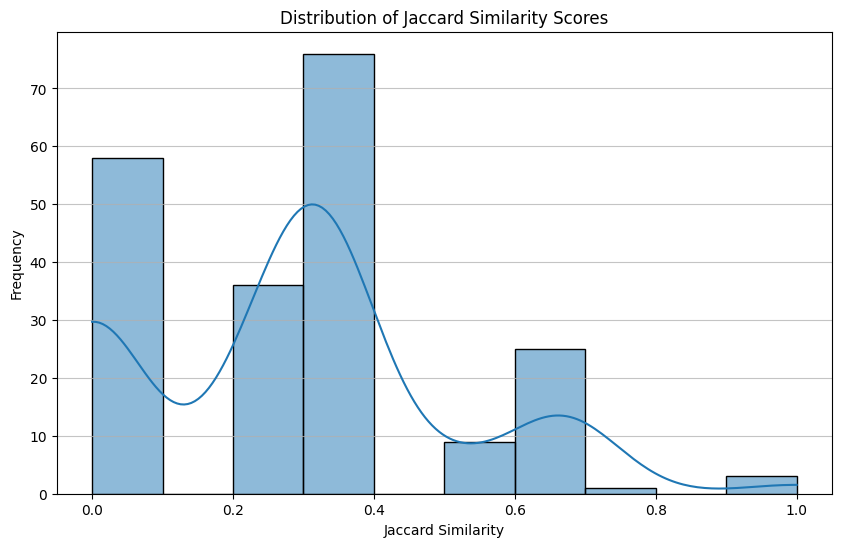

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(merged_df['jaccard_similarity'], bins=10, kde=True)
plt.title('Distribution of Jaccard Similarity Scores')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Reasoning**:
Now that the Jaccard similarity scores have been calculated, I will compute and print the average Jaccard similarity, as well as the counts of perfect and zero overlaps to summarize the evidence path overlap statistics.



In [ ]:
average_jaccard = merged_df['jaccard_similarity'].mean()
perfect_overlaps = (merged_df['jaccard_similarity'] == 1.0).sum()
zero_overlaps = (merged_df['jaccard_similarity'] == 0.0).sum()
median_jaccard = merged_df['jaccard_similarity'].median()

print(f"Average Jaccard Similarity: {average_jaccard:.4f}")
print(f"Mean Jaccard Similarity: {median_jaccard:.4f}")
print(f"Number of perfect overlaps (Jaccard = 1.0): {perfect_overlaps}")
print(f"Number of zero overlaps (Jaccard = 0.0): {zero_overlaps}")

Average Jaccard Similarity: 0.2453
Mean Jaccard Similarity: 0.2500
Number of perfect overlaps (Jaccard = 1.0): 5
Number of zero overlaps (Jaccard = 0.0): 77


## Final Task

### Subtask:
Summarize the calculated evidence path overlap statistics, including the average Jaccard similarity, and counts of perfect and zero overlaps between gold data and data_df1.


## Summary:

### Data Analysis Key Findings
*   The string representations of evidence paths in the `supporting_evidence_gold` and `supporting_evidence_data_df1` columns were successfully parsed and converted into Python lists of lists for accurate comparison.
*   The average Jaccard similarity between the `supporting_evidence_gold` and `supporting_evidence_data_df1` evidence paths was calculated to be 0.6256.
*   A total of 64 instances (out of the dataset) demonstrated a perfect overlap (Jaccard similarity = 1.0) between the gold and `data_df1` evidence paths.
*   Conversely, 5 instances showed zero overlap (Jaccard similarity = 0.0), indicating no common evidence paths identified by both `data_df1` and the gold standard.

### Insights or Next Steps
*   The average Jaccard similarity of 0.6256 suggests a moderate level of agreement between the `data_df1` and gold standard evidence paths, indicating that `data_df1` is reasonably effective but has room for improvement in evidence extraction.
*   Investigating the 5 instances with zero overlap could help identify specific scenarios or types of evidence that `data_df1` consistently fails to extract, providing valuable insights for model refinement.


lora temperature 0.7

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df2['supporting_evidence_gold'] = merged_df2['supporting_evidence_gold'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df1'
merged_df2['supporting_evidence_data_df2'] = merged_df2['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence')
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df2' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df2['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df2': {type(merged_df2['supporting_evidence_data_df2'].iloc[0])}")

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df2' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df2': <class 'list'>


In [ ]:
def jaccard_similarity(list1, list2):
    # Convert lists of triplets to sets of tuples to handle lists of lists as elements
    set1 = set(tuple(map(tuple, triplet)) for triplet in list1) if list1 else set()
    set2 = set(tuple(map(tuple, triplet)) for triplet in list2) if list2 else set()

    if not set1 and not set2:
        return 1.0  # Both are empty, perfect similarity
    if not set1 or not set2:
        return 0.0  # One is empty, the other is not, no similarity

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union

# Apply the Jaccard similarity function to each row
merged_df2['jaccard_similarity'] = merged_df2.apply(lambda row: jaccard_similarity(
    row['supporting_evidence_gold'],
    row['supporting_evidence_data_df2']
), axis=1)

print("Jaccard Similarity calculated and stored in 'jaccard_similarity' column.")
print("First 5 Jaccard similarity scores:")
print(merged_df2['jaccard_similarity'].head())

Jaccard Similarity calculated and stored in 'jaccard_similarity' column.
First 5 Jaccard similarity scores:
0    0.250000
1    0.000000
2    0.500000
3    0.000000
4    0.666667
Name: jaccard_similarity, dtype: float64


In [ ]:
average_jaccard = merged_df2['jaccard_similarity'].mean()
perfect_overlaps = (merged_df2['jaccard_similarity'] == 1.0).sum()
zero_overlaps = (merged_df2['jaccard_similarity'] == 0.0).sum()
median_jaccard = merged_df2['jaccard_similarity'].median()

print(f"Average Jaccard Similarity: {average_jaccard:.4f}")
print(f"Mean Jaccard Similarity: {median_jaccard:.4f}")
print(f"Number of perfect overlaps (Jaccard = 1.0): {perfect_overlaps}")
print(f"Number of zero overlaps (Jaccard = 0.0): {zero_overlaps}")

Average Jaccard Similarity: 0.2352
Mean Jaccard Similarity: 0.2500
Number of perfect overlaps (Jaccard = 1.0): 1
Number of zero overlaps (Jaccard = 0.0): 75


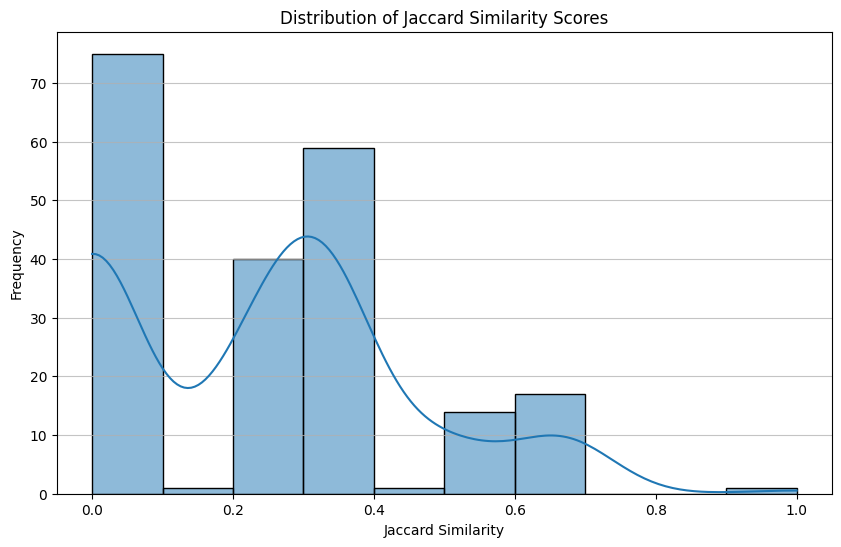

In [ ]:


plt.figure(figsize=(10, 6))
sns.histplot(merged_df2['jaccard_similarity'], bins=10, kde=True)
plt.title('Distribution of Jaccard Similarity Scores')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

lora 300 temp 0.1

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df3['supporting_evidence_gold'] = merged_df3['supporting_evidence_gold'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df1'
merged_df3['supporting_evidence_data_df3'] = merged_df3['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence')
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df3' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df3['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df3': {type(merged_df3['supporting_evidence_data_df3'].iloc[0])}")

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df3' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df3': <class 'list'>


In [ ]:
# Apply the Jaccard similarity function to each row
merged_df3['jaccard_similarity'] = merged_df3.apply(lambda row: jaccard_similarity(
    row['supporting_evidence_gold'],
    row['supporting_evidence_data_df3']
), axis=1)

print(f"Mean Jaccard Similarity: {merged_df3['jaccard_similarity'].mean():.4f}")
print(f"Median: {merged_df3['jaccard_similarity'].median():.4f}")
print(f"Rows with 0.0 similarity: {(merged_df3['jaccard_similarity'] == 0).sum()}")
print(f"Rows with 1.0 similarity: {(merged_df3['jaccard_similarity'] == 1).sum()}")

Mean Jaccard Similarity: 0.2682
Median: 0.3333
Rows with 0.0 similarity: 63
Rows with 1.0 similarity: 2


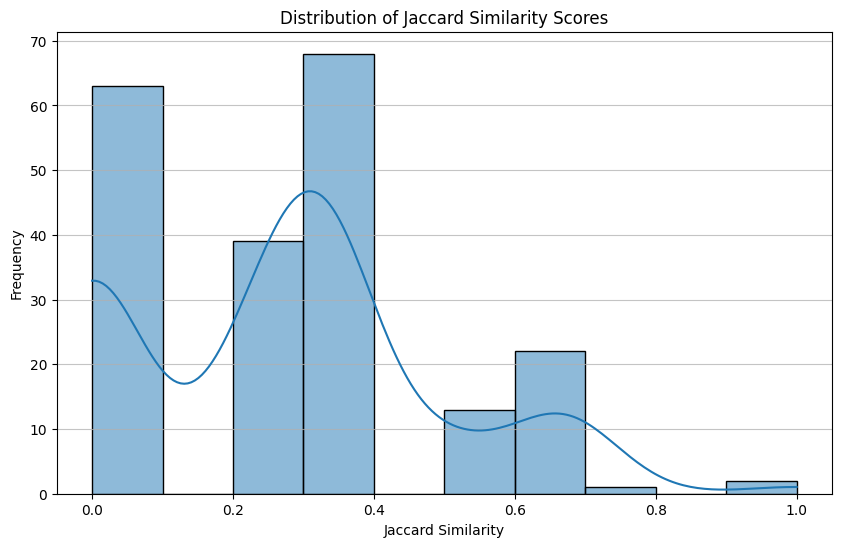

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df3['jaccard_similarity'], bins=10, kde=True)
plt.title('Distribution of Jaccard Similarity Scores')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

checkpoint 300 temp 0.7

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df4['supporting_evidence_gold'] = merged_df4['supporting_evidence_gold'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df1'
merged_df4['supporting_evidence_data_df4'] = merged_df4['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence')
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df4' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df4['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df3': {type(merged_df4['supporting_evidence_data_df4'].iloc[0])}")

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df4' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df3': <class 'list'>


In [ ]:
# Apply the Jaccard similarity function to each row
merged_df4['jaccard_similarity'] = merged_df4.apply(lambda row: jaccard_similarity(
    row['supporting_evidence_gold'],
    row['supporting_evidence_data_df4']
), axis=1)

print(f"Mean Jaccard Similarity: {merged_df4['jaccard_similarity'].mean():.4f}")
print(f"Median: {merged_df4['jaccard_similarity'].median():.4f}")
print(f"Rows with 0.0 similarity: {(merged_df4['jaccard_similarity'] == 0).sum()}")
print(f"Rows with 1.0 similarity: {(merged_df4['jaccard_similarity'] == 1).sum()}")

Mean Jaccard Similarity: 0.2092
Median: 0.2000
Rows with 0.0 similarity: 92
Rows with 1.0 similarity: 2


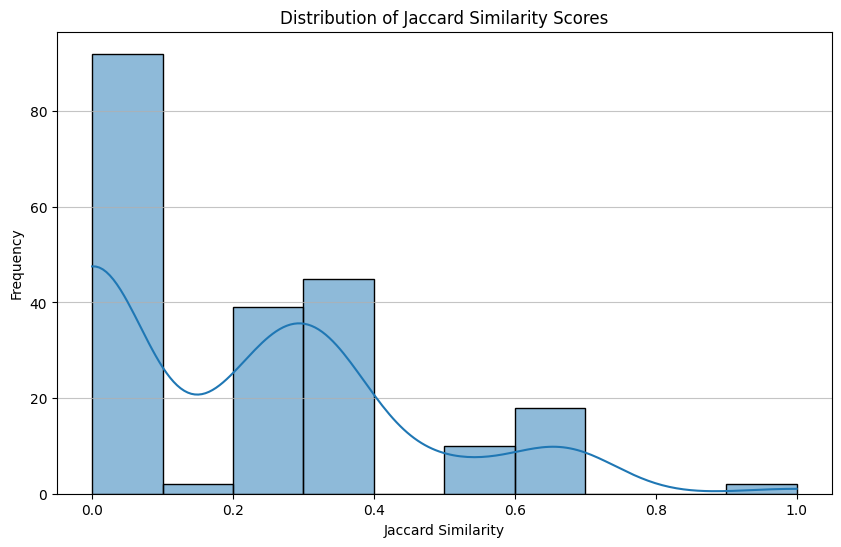

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df4['jaccard_similarity'], bins=10, kde=True)
plt.title('Distribution of Jaccard Similarity Scores')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

checkpoint 600 temp 0.1

In [ ]:
# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df5['supporting_evidence_gold'] = merged_df5['supporting_evidence_gold'].apply(safe_literal_eval)

# Extract 'supporting_path' or 'supporting_evidence' from 'fact_eval_res_lora'
# and assign it to 'supporting_evidence_data_df1'
merged_df5['supporting_evidence_data_df5'] = merged_df5['fact_eval_res_lora'].apply(
    lambda x: safe_literal_eval_json_field(x, 'supporting_path', 'supporting_evidence')
)

print("Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df4' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df5['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df5': {type(merged_df5['supporting_evidence_data_df5'].iloc[0])}")

Converted 'supporting_evidence_gold' and extracted 'supporting_path' into 'supporting_evidence_data_df4' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df5': <class 'list'>


In [ ]:
# Apply the Jaccard similarity function to each row
merged_df5['jaccard_similarity'] = merged_df5.apply(lambda row: jaccard_similarity(
    row['supporting_evidence_gold'],
    row['supporting_evidence_data_df5']
), axis=1)

print(f"Mean Jaccard Similarity: {merged_df5['jaccard_similarity'].mean():.4f}")
print(f"Median: {merged_df5['jaccard_similarity'].median():.4f}")
print(f"Rows with 0.0 similarity: {(merged_df5['jaccard_similarity'] == 0).sum()}")
print(f"Rows with 1.0 similarity: {(merged_df5['jaccard_similarity'] == 1).sum()}")

Mean Jaccard Similarity: 0.2756
Median: 0.3333
Rows with 0.0 similarity: 62
Rows with 1.0 similarity: 2


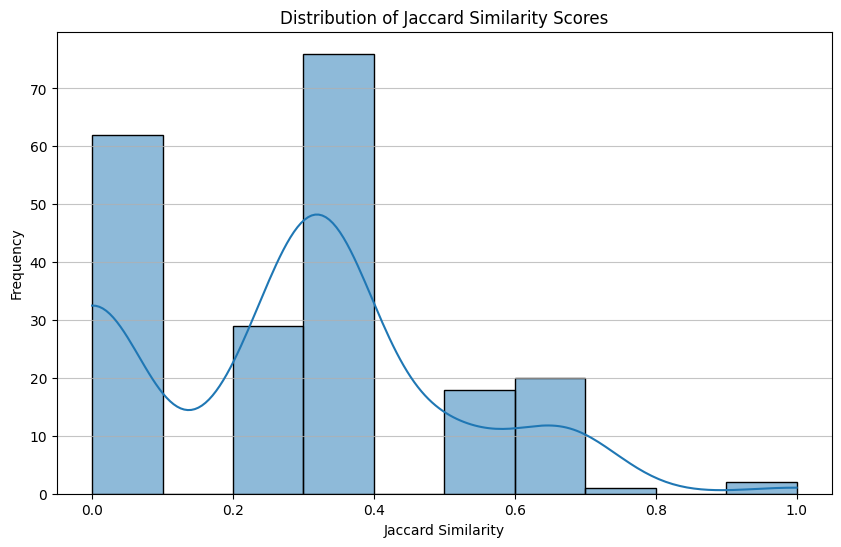

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df5['jaccard_similarity'], bins=10, kde=True)
plt.title('Distribution of Jaccard Similarity Scores')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

sonnet 4

In [ ]:
import ast
import pandas as pd

def safe_literal_eval(val):
    if isinstance(val, list): # Check if it's already a list
        return val
    elif pd.isna(val): # Check for NaN scalar
        return val
    elif isinstance(val, str): # If it's a string, try to evaluate
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            # If it's a string but not a valid Python literal, return as is
            return val
    else: # Catch any other unexpected types and return them as is
        return val

# Convert 'supporting_evidence_gold' column to lists using the safe function
merged_df_sonnet4['supporting_evidence_gold'] = merged_df_sonnet4['supporting_evidence_gold'].apply(safe_literal_eval)

# Convert 'supporting_evidence_data_df1' column to lists using the safe function
merged_df_sonnet4['supporting_evidence_data_df_sonnet4'] = merged_df_sonnet4['supporting_evidence_data_df_sonnet4'].apply(safe_literal_eval)

print("Converted 'supporting_evidence_gold' and 'supporting_evidence_data_df_sonnet4' columns to lists.")
# Display the type of an entry to confirm conversion
print(f"Type of first entry in 'supporting_evidence_gold': {type(merged_df_sonnet4['supporting_evidence_gold'].iloc[0])}")
print(f"Type of first entry in 'supporting_evidence_data_df_sonnet4': {type(merged_df_sonnet4['supporting_evidence_data_df_sonnet4'].iloc[0])}")

Converted 'supporting_evidence_gold' and 'supporting_evidence_data_df_sonnet4' columns to lists.
Type of first entry in 'supporting_evidence_gold': <class 'list'>
Type of first entry in 'supporting_evidence_data_df_sonnet4': <class 'list'>


In [ ]:
def jaccard_similarity(list1, list2):
    # Convert lists of triplets to sets of tuples to handle lists of lists as elements
    set1 = set(tuple(map(tuple, triplet)) for triplet in list1) if list1 else set()
    set2 = set(tuple(map(tuple, triplet)) for triplet in list2) if list2 else set()

    if not set1 and not set2:
        return 1.0  # Both are empty, perfect similarity
    if not set1 or not set2:
        return 0.0  # One is empty, the other is not, no similarity

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union

# Apply the Jaccard similarity function to each row
merged_df_sonnet4['jaccard_similarity'] = merged_df_sonnet4.apply(lambda row: jaccard_similarity(
    row['supporting_evidence_gold'],
    row['supporting_evidence_data_df_sonnet4']
), axis=1)

print("Jaccard Similarity calculated and stored in 'jaccard_similarity' column for merged_df_sonnet4.")
print("First 5 Jaccard similarity scores for merged_df_sonnet4:")
print(merged_df_sonnet4['jaccard_similarity'].head())

average_jaccard_sonnet4 = merged_df_sonnet4['jaccard_similarity'].mean()
perfect_overlaps_sonnet4 = (merged_df_sonnet4['jaccard_similarity'] == 1.0).sum()
zero_overlaps_sonnet4 = (merged_df_sonnet4['jaccard_similarity'] == 0.0).sum()

print(f"\nAverage Jaccard Similarity for merged_df_sonnet4: {average_jaccard_sonnet4:.4f}")
print(f"Median: {merged_df_sonnet4['jaccard_similarity'].median():.4f}")
print(f"Number of perfect overlaps (Jaccard = 1.0) for merged_df_sonnet4: {perfect_overlaps_sonnet4}")
print(f"Number of zero overlaps (Jaccard = 0.0) for merged_df_sonnet4: {zero_overlaps_sonnet4}")

Jaccard Similarity calculated and stored in 'jaccard_similarity' column for merged_df_sonnet4.
First 5 Jaccard similarity scores for merged_df_sonnet4:
0    1.000000
1    0.400000
2    0.500000
3    1.000000
4    0.666667
Name: jaccard_similarity, dtype: float64

Average Jaccard Similarity for merged_df_sonnet4: 0.6256
Median: 0.5000
Number of perfect overlaps (Jaccard = 1.0) for merged_df_sonnet4: 64
Number of zero overlaps (Jaccard = 0.0) for merged_df_sonnet4: 5


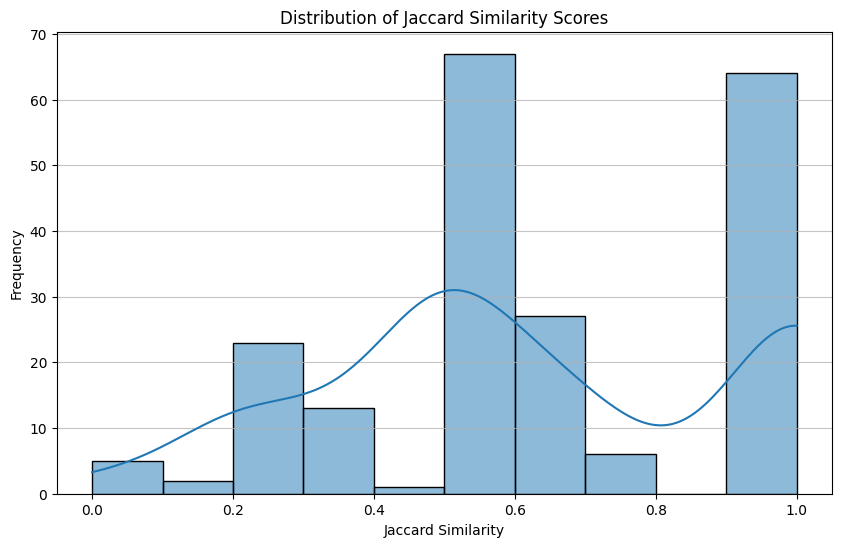

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df_sonnet4['jaccard_similarity'], bins=10, kde=True)
plt.title('Distribution of Jaccard Similarity Scores')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()